# 1. Data Exploration and Preprocessing

##	Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.

In [3]:
import pandas as pd

In [7]:
df=pd.read_csv('blogs.csv')

In [9]:
# Display the basic information about the dataset

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [13]:
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [15]:
# Checking for missing values

In [19]:
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [21]:
# Understand the distribution of categories

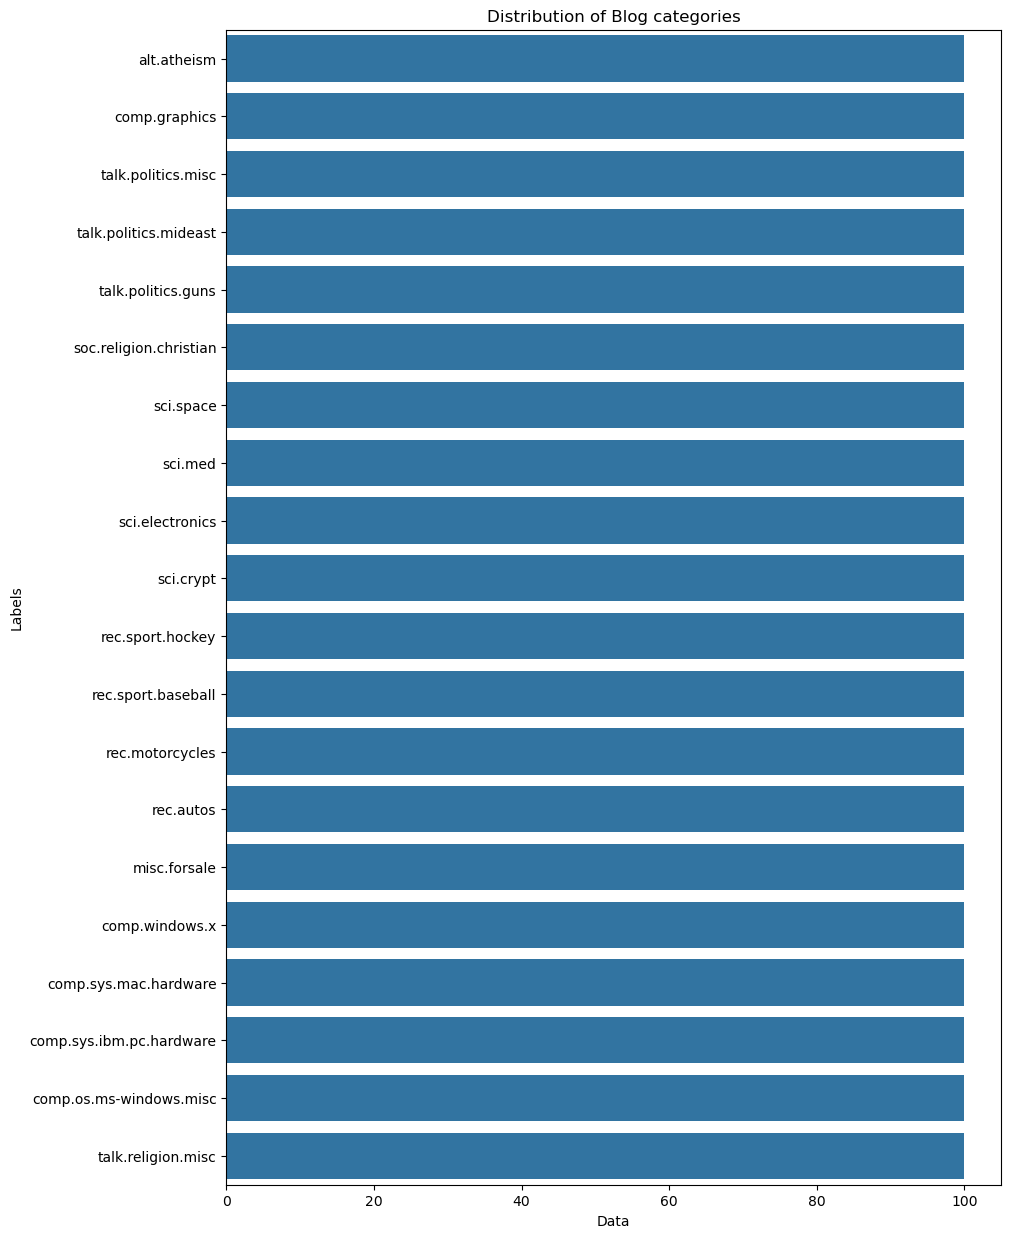

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


# Count the number of samples per category

plt.figure(figsize=(10,15))

# visualizing categorical data using a count plot in Python with Seaborn

# sns.countplot(): Creates a count plot, which shows the frequency of each category in the specified data column.
# y=df['Labels']: Specifies the column Labels in the DataFrame df for the y-axis (categories).
# order=df['Labels'].value_counts().index: Orders the categories based on their frequency in descending order.

sns.countplot(y=df['Labels'], order=df['Labels'].value_counts().index)

plt.title('Distribution of Blog categories')
plt.xlabel('Data')
plt.ylabel('Labels')
plt.show()

In [ ]:
# Analyze Text Data (Length, Word Count, etc.)

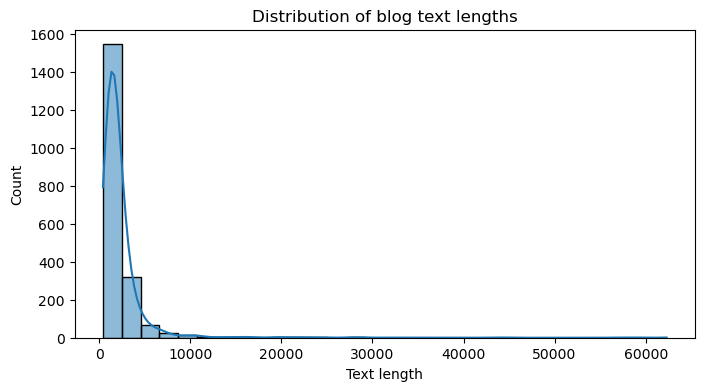

In [39]:
# Add a new column for text length
df['text_length']=df['Data'].apply(len)

# Visualize text length distribution

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'],bins=30, kde=True)
plt.title('Distribution of blog text lengths')
plt.xlabel('Text length')
plt.show()

In [41]:
df

,Data,Labels,text_length
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,5972
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,1336
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,3116
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,15910
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,3264
...,...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc,5263
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,1771
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc,2192
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,3197


In [43]:
# Check for class imbalance

In [47]:
category_counts=df['Labels'].value_counts()
print ("Category distribution :\n", category_counts)


Category distribution :
 Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64


In [49]:
# Basic text analysis (Word cloud)


In [55]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


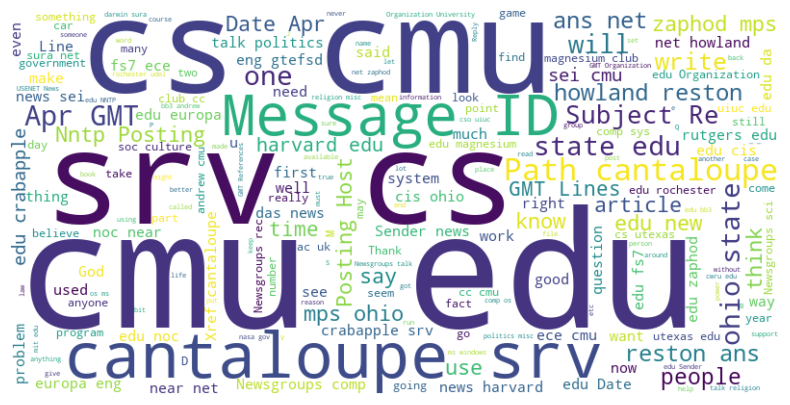

In [57]:
from wordcloud import WordCloud

# Combine all text into one large string

all_text = ' '.join(df['Data'])

# Generate a word cloud

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [61]:
# Check for duplicate entries

In [65]:
# Count duplicate rows

duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

Number of duplicate rows: 0


## 	Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.

In [110]:
pip install spacy


   ---------------------------------------- 0.0/11.8 MB ? eta -:--:--
    --------------------------------------- 0.3/11.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/11.8 MB 3.1 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.8 MB 4.1 MB/s eta 0:00:03
   ------------- -------------------------- 3.9/11.8 MB 5.2 MB/s eta 0:00:02
   --------------------- ------------------ 6.3/11.8 MB 6.5 MB/s eta 0:00:01
   ----------------------------- ---------- 8.7/11.8 MB 7.5 MB/s eta 0:00:01
   -------------------------------------- - 11.3/11.8 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 11.8/11.8 MB 8.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/632.6 kB ? eta -:--:--
   ---------------------------------------- 632.6/632.6 kB 7.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------------

In [114]:
!python -m spacy download en_core_web_sm


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 11.2 MB/s eta 0:00:01
     ------------- -------------------------- 4.5/12.8 MB 11.7 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 11.8 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 11.9 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 11.6 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 11.2 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [118]:
import spacy
import re
import string


# Load spaCy model
nlp=spacy.load("en_core_web_sm")

def preprocess_text(text):

    # Remove specific characters like quotes
    text = text.translate(str.maketrans("","",string.punctuation))

    # Remove words containing numbers and standalone numbers
    text = re.sub(r'\b\w*\d\w*\b',"",text) # Removes words with numbers 
    text = re.sub(r'\b\d+\b',"",text) # Removes standalone numbers

    # Process with spaCy
    doc = nlp(text.lower()) # Convert to lower case and tokenize

    # Lemmatize, remove stopwords, and keep only alphabetic tokens
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]

    return " ".join(tokens)

# Apply preprocessing to Data column
df["Cleaned_Text"] = df["Data"].apply(preprocess_text)

# Display first few rows
print (df[['Data','Cleaned_Text']].head())

                                                Data  \
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....   
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...   
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...   

                                        Cleaned_Text  
0  path frank odwyer newsgroup altatheism subject...  
1  newsgroups altatheism path bilokcforumosrheedu...  
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  
3  path jbrownbatmanbmdtrwcom newsgroup altatheis...  
4  xref cantaloupesrvcscmuedu newsgroup altatheis...  


In [ ]:
# text = text.translate(str.maketrans("","",string.punctuation))

# This line of code is used to remove punctuation from a string in Python. Here's a breakdown of what it does:
# str.maketrans("", "", string.punctuation): Creates a translation table to map all punctuation characters to None.
# The first two "" parameters mean no substitution is being made.
# The third parameter, string.punctuation, specifies the characters to remove (e.g., !"#$%&'()*+,-./:;<=>?@[\]^_{|}~`).
# text.translate(): Applies the translation table to the string text, effectively removing all punctuation.


# text = re.sub(r'\b\w*\d\w*\b',"",text) # Removes words with numbers 
# text = re.sub(r'\b\d+\b',"",text) # Removes standalone numbers


# These lines of code use the re.sub() function from the re (regular expression) module in Python to clean the text by removing unwanted patterns. 
# Here's what they do:

# 1. text = re.sub(r'\b\w*\d\w*\b',"",text):

# Regex Pattern: \b\w*\d\w*\b
# \b: Word boundary ensures entire words are matched.
# \w*: Matches zero or more alphanumeric characters (letters, digits, or underscores) before a digit.
# \d: Matches any digit.
# \w*: Matches zero or more alphanumeric characters after the digit.

# Purpose: Removes entire words that contain numbers.
# Example: Input: "My user1name is cool123 but 42cats are random." Output: "My is but cats are random."

# 2. text = re.sub(r'\b\d+\b',"",text):

# Regex Pattern: \b\d+\b
# \b: Word boundary ensures entire numbers are matched.
# \d+: Matches one or more digits.

# Purpose: Removes standalone numbers (words that consist entirely of digits).
# Example: Input: "I have 42 cats and 1000 dreams." Output: "I have cats and dreams."

# Combined Effect:
# These lines of code ensure that:

# Words containing any numbers are removed.

# Entire standalone numbers are also removed.

## Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.

In [121]:
# Checking the vocabulary size


from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df['Cleaned_Text'])

print(f"Total unique words in dataset: {len(vectorizer.get_feature_names_out())}")

Total unique words in dataset: 33528


In [ ]:
# Choosing the Right Naive Bayes Variant:
# Use Multinomial: When your input features are word counts, term frequencies, or TF-IDF scores.

# Use Gaussian: When your input features are numeric and continuous.

# Use Bernoulli (Binary): When your input features are binary (presence/absence).

In [133]:
# Performing Grid Search CV for optimum max_features

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

# Define possible values of max_features
feature_sizes = [1000, 3000, 5000, 7000, 10000, 15000, 20000, 25000, 30000, 33000, None]

for size in feature_sizes:
    tfidf_vectorizer = TfidfVectorizer(max_features=size)
    X_tfidf = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])

    # Train a simple Naive Bayes model
    model = MultinomialNB()
    scores = cross_val_score(model, X_tfidf, df['Labels'], cv=5, scoring = 'accuracy')

    print (f"max_features={size}: Mean Accuraccy= {scores.mean():.4f}")


max_features=1000: Mean Accuraccy= 0.7835
max_features=3000: Mean Accuraccy= 0.8300
max_features=5000: Mean Accuraccy= 0.8355
max_features=7000: Mean Accuraccy= 0.8370
max_features=10000: Mean Accuraccy= 0.8375
max_features=15000: Mean Accuraccy= 0.8370
max_features=20000: Mean Accuraccy= 0.8350
max_features=25000: Mean Accuraccy= 0.8340
max_features=30000: Mean Accuraccy= 0.8340
max_features=33000: Mean Accuraccy= 0.8335
max_features=None: Mean Accuraccy= 0.8335


In [ ]:
# Optimum max_features = 10000

In [ ]:
# To prepare the text data for a Naive Bayes classifier, you need to convert it into a numerical format. One common technique is TF-IDF 
# (Term Frequency-Inverse Document Frequency). Below is how you can perform TF-IDF feature extraction in Python:

In [131]:
# Steps to Perform TF-IDF Feature Extraction
# 1. Convert cleaned text into TF-IDF vectors using TfidfVectorizer.

# 2. Ensure it’s suitable for training a Naive Bayes model.


from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features = 10000) # Limit features to avoid overfitting


# Fit and transform the cleaned text column
X_tfidf = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])

# Convert to dataframe for better visualization
import pandas as pd
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Display first few rows of TF-IDF features
print (tfidf_df.head())

    aa  aan  aapwamumdedu  aaron   ab  abandon  abate       abc  abdulla  \
0  0.0  0.0           0.0    0.0  0.0      0.0    0.0  0.000000      0.0   
1  0.0  0.0           0.0    0.0  0.0      0.0    0.0  0.000000      0.0   
2  0.0  0.0           0.0    0.0  0.0      0.0    0.0  0.000000      0.0   
3  0.0  0.0           0.0    0.0  0.0      0.0    0.0  0.022311      0.0   
4  0.0  0.0           0.0    0.0  0.0      0.0    0.0  0.000000      0.0   

   ability  ...  zone  zoology  zoom  zphig  zrepacholcccurtineduau  zterm  \
0      0.0  ...   0.0      0.0   0.0    0.0                     0.0    0.0   
1      0.0  ...   0.0      0.0   0.0    0.0                     0.0    0.0   
2      0.0  ...   0.0      0.0   0.0    0.0                     0.0    0.0   
3      0.0  ...   0.0      0.0   0.0    0.0                     0.0    0.0   
4      0.0  ...   0.0      0.0   0.0    0.0                     0.0    0.0   

   zubair  zucker  zyxel   zz  
0     0.0     0.0    0.0  0.0  
1     0.0 

In [135]:
# In the context of TfidfVectorizer (or similar vectorizers in scikit-learn), 
# the parameter max_features=10000 means that the vectorizer will consider only the top 10,000 most frequent terms (or features) 
# from the text data when building the vocabulary.

## 2. Naive Bayes Model for Text Classification

In [ ]:
# •	Split the data into training and test sets.
# •	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like 
# scikit-learn for this purpose.
# •	Train the model on the training set and make predictions on the test set.


In [138]:
# import necessary libraries

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

df

,Data,Labels,Cleaned_Text
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,path frank odwyer newsgroup altatheism subject...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,newsgroups altatheism path bilokcforumosrheedu...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,path cantaloupesrvcscmuedudasnewsharvardedunoc...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,path jbrownbatmanbmdtrwcom newsgroup altatheis...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,xref cantaloupesrvcscmuedu newsgroup altatheis...
...,...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc,xref cantaloupesrvcscmuedu path frank odwyer n...
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,xref cantaloupesrvcscmuedu newsgroup talkrelig...
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc,xref cantaloupesrvcscmuedu path cantaloupesrvc...
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,xref cantaloupesrvcscmuedu path cantaloupesrvc...


In [144]:
# Split data into training and test sets

X = df['Cleaned_Text'] #Features processed text
Y = df['Labels'] # Target labels

# Split into 80% training and 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)



In [146]:
# Convert text data to numerical format (TF-IDF)

tfidf_vectorizer = TfidfVectorizer(max_features=10000) # Adjust max_features as needed
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [148]:
# Train Naive Bayes model

# Initialize and train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)


MultinomialNB()

In [150]:
# Make predictions

# Predict on test data
y_pred = nb_model.predict(X_test_tfidf)

In [152]:
# Evaluate model performance

# Print accuracy
accuracy = accuracy_score(Y_test, y_pred)
print (f"Model accuracy : {accuracy:.4f}")

# Print classification report (Precision, Recall, F1-score)
print ("\n Classification Report:\n", classification_report(Y_test, y_pred))

Model accuracy : 0.8100

 Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.70      0.70      0.70        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.76      0.80      0.78        20
comp.sys.ibm.pc.hardware       0.56      0.75      0.64        20
   comp.sys.mac.hardware       0.81      0.65      0.72        20
          comp.windows.x       0.94      0.75      0.83        20
            misc.forsale       0.90      0.90      0.90        20
               rec.autos       0.90      0.90      0.90        20
         rec.motorcycles       0.90      0.90      0.90        20
      rec.sport.baseball       0.91      1.00      0.95        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.83      1.00      0.91        20
         sci.electronics       0.83      0.75      0.79        20
                 sci.med 

# 3. Sentiment Analysis

In [ ]:
# •	Choose a suitable library or method for performing sentiment analysis on the blog post texts.
# •	Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. 
#  Consider only the Data column and get the sentiment for each blog.
# •	Examine the distribution of sentiments across different categories and summarize your findings.


In [ ]:
# The library VADER (for short texts) or TextBlob can be used for sentiment analysis.
# If the data is longer, more complex text, then transformers (Hugging Face) BERT models work better.
# In this task, VADER is used which is part of nltk, since it is good for quick sentiment classification.                    

In [159]:
# Perform Sentiment analysis on blog posts

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Download VADER sentiment analyzer
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Function to analyze sentiment
def get_sentiment(text):
    sentiment_score = sia.polarity_scores(text)['compound']
    if sentiment_score >=0.05:
        return 'Positive'
    elif sentiment_score <=-0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply sentiment analysis to each blog post
df['Sentiment'] = df['Cleaned_Text'].apply(get_sentiment)

# Display some results
print (df[['Cleaned_Text','Sentiment']].head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Smrithi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                        Cleaned_Text Sentiment
0  path frank odwyer newsgroup altatheism subject...  Negative
1  newsgroups altatheism path bilokcforumosrheedu...  Positive
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  Negative
3  path jbrownbatmanbmdtrwcom newsgroup altatheis...  Negative
4  xref cantaloupesrvcscmuedu newsgroup altatheis...  Positive


In [161]:
df

,Data,Labels,Cleaned_Text,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,path frank odwyer newsgroup altatheism subject...,Negative
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,newsgroups altatheism path bilokcforumosrheedu...,Positive
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,path cantaloupesrvcscmuedudasnewsharvardedunoc...,Negative
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,path jbrownbatmanbmdtrwcom newsgroup altatheis...,Negative
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,xref cantaloupesrvcscmuedu newsgroup altatheis...,Positive
...,...,...,...,...
1995,Xref: cantaloupe.srv.cs.cmu.edu talk.abortion:...,talk.religion.misc,xref cantaloupesrvcscmuedu path frank odwyer n...,Positive
1996,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,xref cantaloupesrvcscmuedu newsgroup talkrelig...,Positive
1997,Xref: cantaloupe.srv.cs.cmu.edu talk.origins:4...,talk.religion.misc,xref cantaloupesrvcscmuedu path cantaloupesrvc...,Positive
1998,Xref: cantaloupe.srv.cs.cmu.edu talk.religion....,talk.religion.misc,xref cantaloupesrvcscmuedu path cantaloupesrvc...,Positive


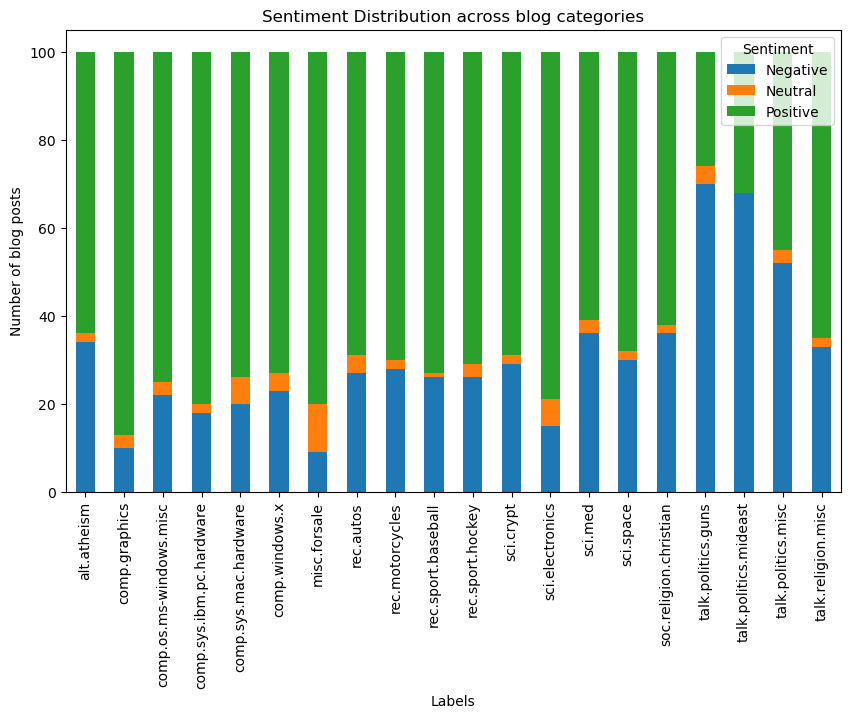

In [167]:
# Examine the sentiment distribution across categories

import seaborn as sns
import matplotlib.pyplot as plt

# Count sentiment distribution in each category
sentiment_distribution = df.groupby('Labels')['Sentiment'].value_counts().unstack()

# Plot the sentiment distribution
sentiment_distribution.plot(kind = 'bar', stacked = True, figsize= (10,6))
plt.title ('Sentiment Distribution across blog categories')
plt.xlabel('Labels')
plt.ylabel('Number of blog posts')
plt.legend(title = 'Sentiment')
plt.show()


In [169]:
# Code to Display Sentiment Distribution in Numbers
sentiment_distribution = df.groupby('Labels')['Sentiment'].value_counts().unstack()

In [171]:
# Display as a table

print (sentiment_distribution)

Sentiment                 Negative  Neutral  Positive
Labels                                               
alt.atheism                   34.0      2.0      64.0
comp.graphics                 10.0      3.0      87.0
comp.os.ms-windows.misc       22.0      3.0      75.0
comp.sys.ibm.pc.hardware      18.0      2.0      80.0
comp.sys.mac.hardware         20.0      6.0      74.0
comp.windows.x                23.0      4.0      73.0
misc.forsale                   9.0     11.0      80.0
rec.autos                     27.0      4.0      69.0
rec.motorcycles               28.0      2.0      70.0
rec.sport.baseball            26.0      1.0      73.0
rec.sport.hockey              26.0      3.0      71.0
sci.crypt                     29.0      2.0      69.0
sci.electronics               15.0      6.0      79.0
sci.med                       36.0      3.0      61.0
sci.space                     30.0      2.0      68.0
soc.religion.christian        36.0      2.0      62.0
talk.politics.guns          

In [179]:
 # Code to Sort by Positive Sentiment Count

# Sort the dataframe by the 'Positive' column in descending order

sentiment_distribution_sorted = sentiment_distribution.sort_values(by='Positive',ascending=False)

sentiment_distribution_sorted

Sentiment,Negative,Neutral,Positive
Labels,,,
comp.graphics,10.0,3.0,87.0
comp.sys.ibm.pc.hardware,18.0,2.0,80.0
misc.forsale,9.0,11.0,80.0
sci.electronics,15.0,6.0,79.0
comp.os.ms-windows.misc,22.0,3.0,75.0
comp.sys.mac.hardware,20.0,6.0,74.0
comp.windows.x,23.0,4.0,73.0
rec.sport.baseball,26.0,1.0,73.0
rec.sport.hockey,26.0,3.0,71.0


In [ ]:
Inference-

It can be seen that the most number of positive blog posts were under the category comp.graphics with 87 positive comments, which is followed by
comp.sys.ibm.pc.hardware and misc.forsale with 80 each.

It can also be noted that misc.forsale had the most number of neutral posts which was 11.

The category with the most negative posts were under talk.politics.misc, talk.politics.mideast and talk.politics.gun with less than 50% positive blogs.

There are no neutral posts for talk.politics.mideast unlike all other categories.